In [55]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymutspec.draw import plot_mutspec192, plot_mutspec12, sbs_orders

import warnings
warnings.filterwarnings("ignore")

In [56]:
mutspecs = pd.read_csv('./initial data/MutSpecVertebrates12.csv.gz')
mutspecs = mutspecs.fillna(0)
mutspecs.head()

,Gene,Class,Species,Mut,Observed,Expected,MutSpec
0,CO1,Mammalia,Crocuta_crocuta,A>C,0.000000,115.066667,0.000000
1,CO1,Mammalia,Crocuta_crocuta,A>G,11.500444,173.333333,0.162818
2,CO1,Mammalia,Crocuta_crocuta,A>T,0.000000,115.066667,0.000000
3,CO1,Mammalia,Crocuta_crocuta,C>A,0.000000,71.466667,0.000000
4,CO1,Mammalia,Crocuta_crocuta,C>G,0.000000,71.466667,0.000000


In [57]:
mutspecs.Gene.value_counts()

Gene
Cytb    20364
ND2     10200
CO1      2472
CO3      1356
Name: count, dtype: int64

In [58]:
# Function to translate mutspec from light to heavy chain
def getrevers(mut):
    translator = str.maketrans("ACGT", "TGCA")
    #new_mut = mut[-1] +  mut[1:-1] + mut[0]
    new_mut = mut.translate(translator)
    return new_mut

In [59]:
mutspecs['Mut'] = mutspecs.Mut.apply(getrevers)
#mutspecs["MutBase"] = mutspecs.Mut.str.slice(2, 5)
#mutspecs["Context"] = mutspecs.Mut.str.get(0) + mutspecs.Mut.str.get(2) + mutspecs.Mut.str.get(-1)
mutspecs.head()

,Gene,Class,Species,Mut,Observed,Expected,MutSpec
0,CO1,Mammalia,Crocuta_crocuta,T>G,0.000000,115.066667,0.000000
1,CO1,Mammalia,Crocuta_crocuta,T>C,11.500444,173.333333,0.162818
2,CO1,Mammalia,Crocuta_crocuta,T>A,0.000000,115.066667,0.000000
3,CO1,Mammalia,Crocuta_crocuta,G>T,0.000000,71.466667,0.000000
4,CO1,Mammalia,Crocuta_crocuta,G>C,0.000000,71.466667,0.000000


### Make sum specific by each species and gene 

In [60]:
mutspecs['MutSpec12'] = mutspecs.groupby(['Species', 'Gene', "Mut"])['MutSpec'].transform('sum')

In [61]:
mutspecs.head()

,Gene,Class,Species,Mut,Observed,Expected,MutSpec,MutSpec12
0,CO1,Mammalia,Crocuta_crocuta,T>G,0.000000,115.066667,0.000000,0.000000
1,CO1,Mammalia,Crocuta_crocuta,T>C,11.500444,173.333333,0.162818,0.162818
2,CO1,Mammalia,Crocuta_crocuta,T>A,0.000000,115.066667,0.000000,0.000000
3,CO1,Mammalia,Crocuta_crocuta,G>T,0.000000,71.466667,0.000000,0.000000
4,CO1,Mammalia,Crocuta_crocuta,G>C,0.000000,71.466667,0.000000,0.000000


### Check that Mutspec is on a heavy chain (for example only CytB gene)
Most common 12 comp Mutation are C>T and A>G, so it's heavy chain 

In [62]:
mutspecs.loc[mutspecs.Gene.eq('Cytb')].groupby(['Mut']).MutSpec12.mean().reset_index().sort_values(by='MutSpec12', ascending=False).head(5)

,Mut,MutSpec12
5,C>T,0.478227
1,A>G,0.192529
6,G>A,0.110528
10,T>C,0.093944
4,C>G,0.029145


In [63]:
_ct_mt = mutspecs.loc[mutspecs['Mut'].eq('C>T')]
gene_order = ["ND2", "CO1", "CO3", "Cytb"]

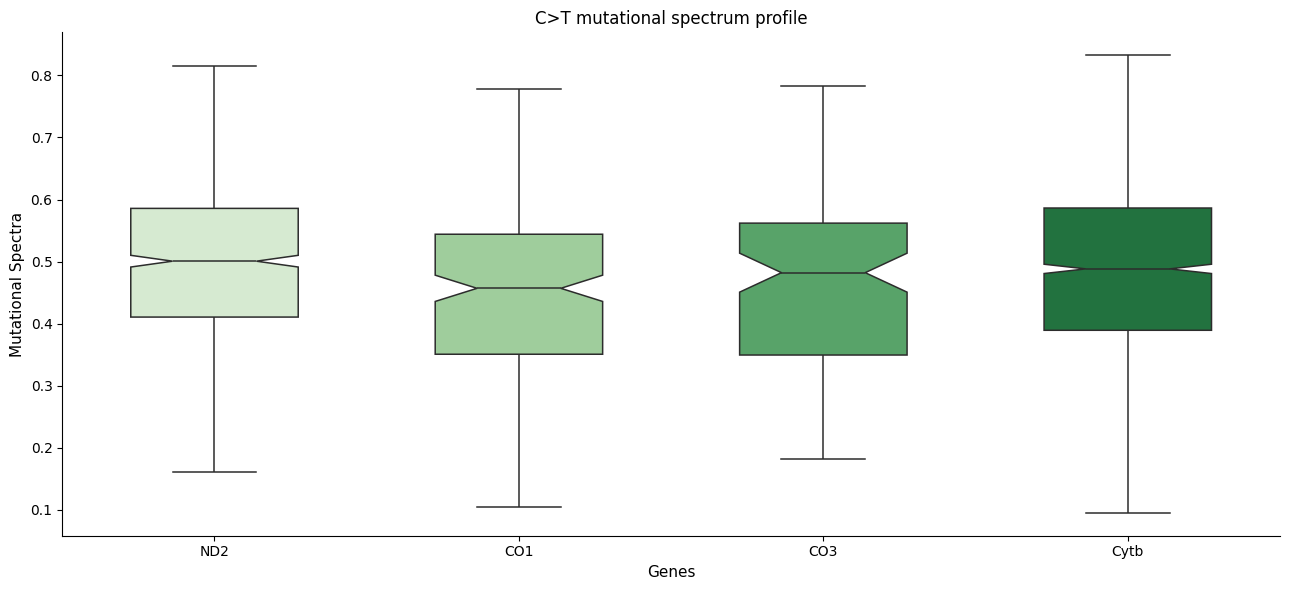

: 

In [ ]:
plt.figure(figsize=(13, 6))

ax = sns.boxplot(
    data=_ct_mt,
    x="Gene", y="MutSpec",
    order=gene_order,
    notch=True,
    width=0.55,
    linewidth=1.1,
    showfliers=False,
    palette="Greens"
)

ax.set_xlabel("Genes", fontsize=11)
ax.set_ylabel("Mutational Spectra", fontsize=11)
ax.set_title("C>T mutational spectrum profile", fontsize=12)

sns.despine(ax=ax)

# Легенда как в статье
ax.legend(title="", frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

### Filter dataset to make sure that each gene is represented by common species

In [ ]:
species_gene_counts = _ct_mt.groupby("Species")["Gene"].nunique()

In [ ]:
common_species = species_gene_counts[species_gene_counts == 4].index
df_common_CT = _ct_mt[_ct_mt["Species"].isin(common_species)].copy()

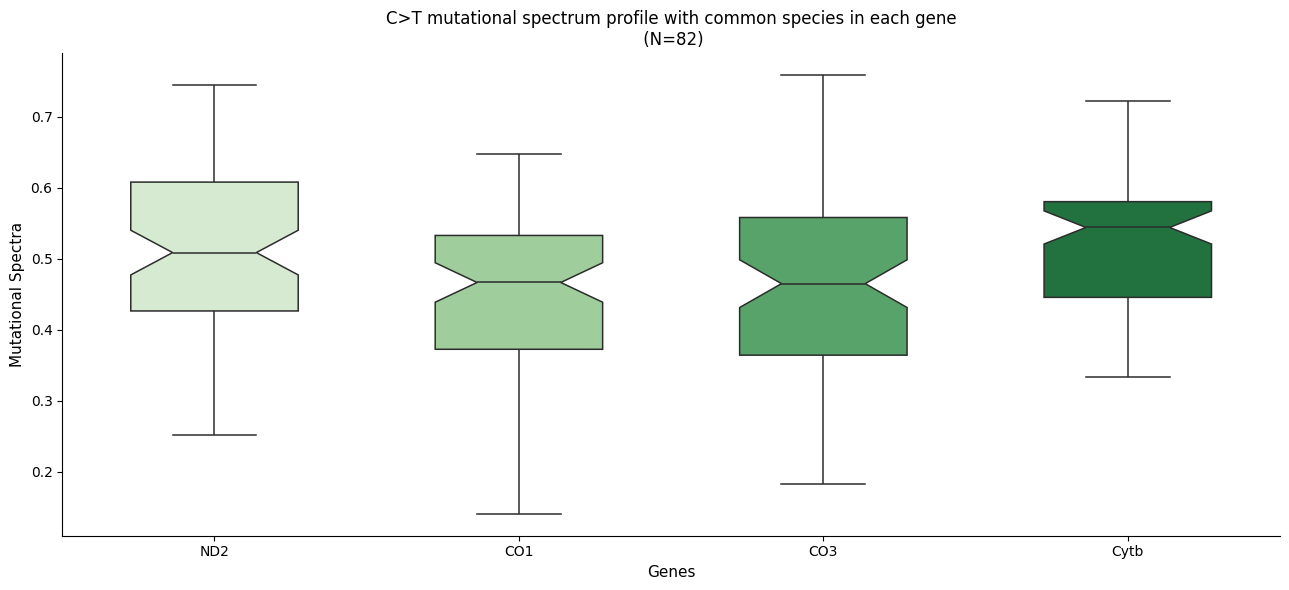

In [ ]:
plt.figure(figsize=(13, 6))

ax = sns.boxplot(
    data=df_common_CT,
    x="Gene", y="MutSpec",
    order=gene_order,
    notch=True,
    width=0.55,
    linewidth=1.1,
    showfliers=False,
    palette="Greens"
)

ax.set_xlabel("Genes", fontsize=11)
ax.set_ylabel("Mutational Spectra", fontsize=11)
ax.set_title("C>T mutational spectrum profile with common species in each gene\n (N=82)", fontsize=12)

sns.despine(ax=ax)

# Легенда как в статье
ax.legend(title="", frameon=False, loc="upper right")

plt.tight_layout()
plt.show()